Graficar 3 señales de physionet y colocarlo en el github(Sesion 3 en la carpeta labs)
Colocar nuestras fotos en el github

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.


# Primera señal
En este caso usaremos un dataset de [Brno University of Technology ECG Signal Database with Annotations of P Wave (BUT PDB)](https://physionet.org/content/but-pdb/1.0.0/)

In [ ]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

## 1. Configurar los parámetros del registro
## Usaremos el registro '01' (que contiene bloqueos de rama derecha según tu tabla)

In [ ]:
record_name = '01'
pn_dir = 'but-pdb/1.0.0' # Directorio exacto en PhysioNet

## 2. Leer el registro y las anotaciones desde la web

In [ ]:
print(f"Descargando registro {record_name}...")
record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
ann_qrs = wfdb.rdann(record_name, 'qrs', pn_dir=pn_dir)
ann_p = wfdb.rdann(record_name, 'pwave', pn_dir=pn_dir)

Descargando registro 01...


## 3. Definir una ventana de tiempo (ej. primeros 5 segundos) para que sea visible

In [ ]:
fs = record.fs  # Frecuencia de muestreo (Hz)
start_sec = 0
end_sec = 5

start_samp = int(start_sec * fs)
end_samp = int(end_sec * fs)

## 4. Extraer los datos de la señal (Usaremos el Canal 0) y crear el eje de tiempo

In [ ]:
signal = record.p_signal[start_samp:end_samp, 0]
time_axis = np.arange(start_samp, end_samp) / fs

## 5. Filtrar las anotaciones para que solo muestren las que caen en nuestros 5 segundos

In [ ]:
qrs_indices = ann_qrs.sample[(ann_qrs.sample >= start_samp) & (ann_qrs.sample < end_samp)]
p_indices = ann_p.sample[(ann_p.sample >= start_samp) & (ann_p.sample < end_samp)]

## 6. Crear la gráfica con Matplotlib

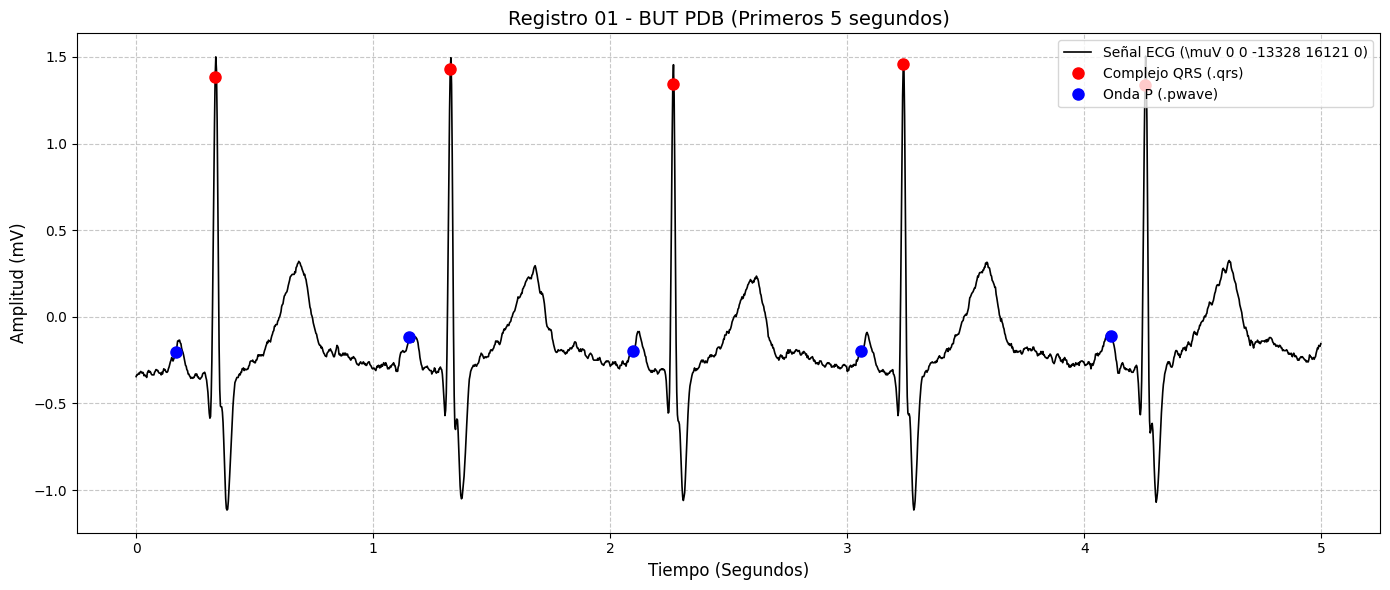

In [ ]:

plt.figure(figsize=(14, 6))

# Graficar la señal de ECG continua
plt.plot(time_axis, signal, label=f'Señal ECG ({record.sig_name[0]})', color='black', linewidth=1.2)

# Superponer los marcadores de las anotaciones
plt.plot(qrs_indices / fs, record.p_signal[qrs_indices, 0], 'ro', markersize=8, label='Complejo QRS (.qrs)')
plt.plot(p_indices / fs, record.p_signal[p_indices, 0], 'bo', markersize=8, label='Onda P (.pwave)')

# Formato estético de la gráfica
plt.title(f'Registro {record_name} - BUT PDB (Primeros {end_sec} segundos)', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel(f'Amplitud ({record.units[0]})', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

## 7. Plotear gráfica en frecuencia

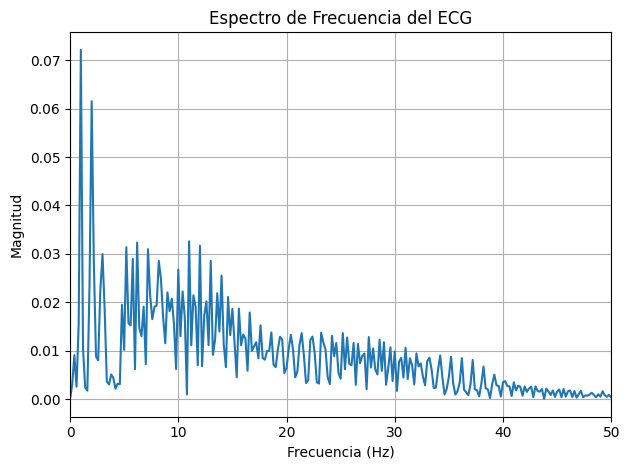

In [ ]:
# PREPROCESAMIENTO (RESTAR MEAN)
signal_centered = signal - np.mean(signal)

#FFT
N = len(signal_centered)

fft_values = np.fft.fft(signal_centered)
freqs = np.fft.fftfreq(N, d=1/fs)

# Solo frecuencias positivas
half_N = N // 2
fft_values = fft_values[:half_N]
freqs = freqs[:half_N]

# Magnitud
magnitude = np.abs(fft_values) / N

plt.figure()

plt.plot(freqs, magnitude)
plt.title('Espectro de Frecuencia del ECG')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')

# Opcional (muy recomendado para ECG)
plt.xlim(0, 50)

plt.grid(True)
plt.tight_layout()
plt.show()


#Segunda señal

Para este caso usaremos el dataset de [MIMIC-IV-ECG: Subconjunto emparejado de electrocardiograma diagnóstico](https://physionet.org/content/mimic-iv-ecg/1.0/)

In [ ]:
# 1. Instalación
!pip install wfdb

import wfdb
import matplotlib.pyplot as plt
import numpy as np

# Ajuste de parámetros
pn_dir = 'mitdb'
record_name = '100'

try:
    print(f"Descargando registro: {record_name}...")

    # Leer señal y anotaciones
    record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)

    # Procesamiento básico
    fs = record.fs
    start_samp = 0
    end_samp = int(5 * fs) # 5 segundos

    signal = record.p_signal[start_samp:end_samp, 0]
    time_axis = np.arange(start_samp, end_samp) / fs

    # Obtener anotaciones dentro del rango
    ann_samples = np.array(annotation.sample)
    ann_symbols = np.array(annotation.symbol)

    mask = (ann_samples >= start_samp) & (ann_samples < end_samp)
    ann_samples_seg = ann_samples[mask]
    ann_symbols_seg = ann_symbols[mask]

    # Identificar QRS (latidos normales 'N')
    qrs_indices = np.array([s for s, sym in zip(ann_samples_seg, ann_symbols_seg)if sym == 'N'])

    # Estimación simple de onda P (antes del QRS)
    p_offset_sec = 0.16
    p_indices = qrs_indices - int(p_offset_sec * fs)

    # Filtrar valores válidos
    p_indices = p_indices[(p_indices >= start_samp) & (p_indices < end_samp)]

except Exception as e:
    print(f"An error occurred: {e}")

Descargando registro: 100...


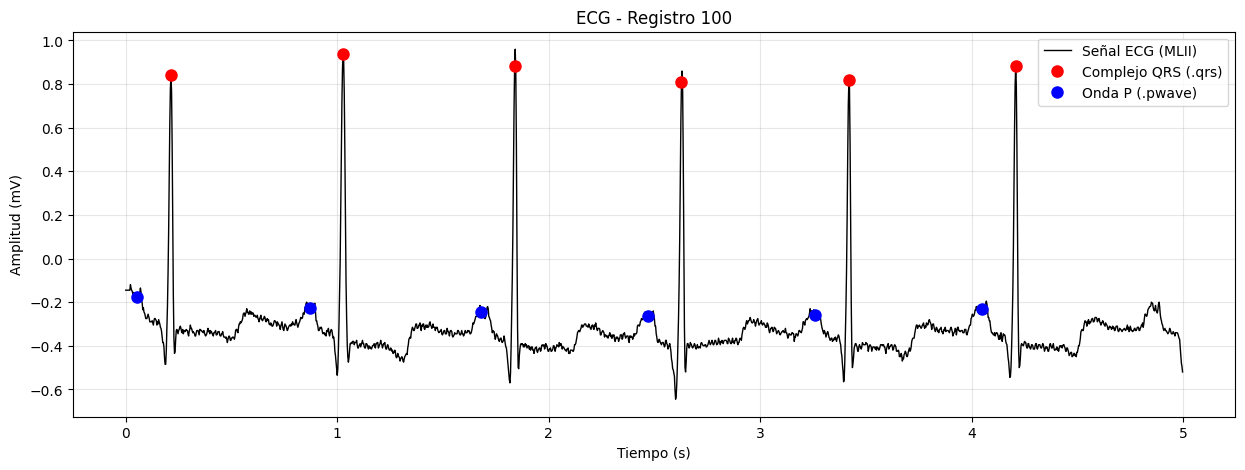

In [ ]:
# Gráfica
# -------------------------
plt.figure(figsize=(15, 5))

# Señal ECG
plt.plot(time_axis, signal, color='black', linewidth=1,label=f'Señal ECG ({record.sig_name[0]})')

# Complejos QRS
plt.plot(qrs_indices / fs,record.p_signal[qrs_indices, 0],'ro', markersize=8,label='Complejo QRS (.qrs)')

# Ondas P
plt.plot(p_indices / fs,record.p_signal[p_indices, 0],'bo', markersize=8,label='Onda P (.pwave)')

# Formato
plt.title(f'ECG - Registro {record.record_name}')
plt.xlabel('Tiempo (s)')
plt.ylabel(f'Amplitud ({record.units[0]})')
plt.grid(True, alpha=0.3)


plt.legend(loc='upper right')

plt.show()

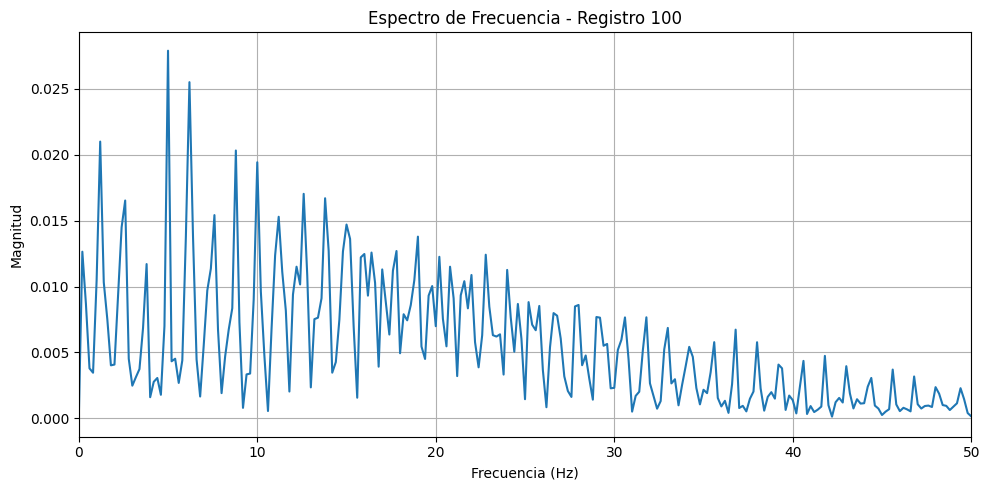

In [ ]:
# PREPROCESAMIENTO (RESTAR MEAN)
signal_centered = signal - np.mean(signal)

#FFT
N = len(signal_centered)

fft_values = np.fft.fft(signal_centered)
freqs = np.fft.fftfreq(N, d=1/fs)

# Solo frecuencias positivas
half_N = N // 2
fft_values = fft_values[:half_N]
freqs = freqs[:half_N]

# Magnitud
magnitude = np.abs(fft_values) / N

plt.figure(figsize=(10, 5))

plt.plot(freqs, magnitude)
plt.title(f'Espectro de Frecuencia - Registro {record.record_name}')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')

# ECG → enfocamos bajas frecuencias
plt.xlim(0, 50)

plt.grid(True)
plt.tight_layout()
plt.show()

#Tercera Señal


Para este caso usaremos el dataset de [MIT-BIH Noise Stress Test Database](https://physionet.org/content/nstdb/1.0.0/)

In [ ]:
# 1. Instalación
!pip install wfdb

import wfdb
import matplotlib.pyplot as plt
import numpy as np

# Ajuste de parámetros
pn_dir = 'nstdb'
record_name = '118e06'   # Prueba también: 118e24, 118e18, 118e12, 118e00, 118e_6
start_sec = 0
end_sec = 5

try:
    print(f"Descargando registro: {record_name}...")

    # Leer señal y anotaciones
    record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)

    fs = record.fs
    start_samp = int(start_sec * fs)
    end_samp = int(end_sec * fs)

    # Señal ECG del canal 0
    signal = record.p_signal[start_samp:end_samp, 0]
    time_axis = np.arange(start_samp, end_samp) / fs

    # Obtener anotaciones dentro del intervalo
    ann_samples = np.array(annotation.sample)
    ann_symbols = np.array(annotation.symbol)

    mask = (ann_samples >= start_samp) & (ann_samples < end_samp)
    ann_samples_seg = ann_samples[mask]
    ann_symbols_seg = ann_symbols[mask]

    # Símbolos típicos de complejos QRS / latidos
    qrs_like_symbols = {'N', 'L', 'R', 'V', 'A', 'a', 'J', 'S', 'e', 'j', 'F', '/', 'f', 'Q'}

    qrs_indices = np.array([
        s for s, sym in zip(ann_samples_seg, ann_symbols_seg)
        if sym in qrs_like_symbols
    ])

    # Estimación simple de onda P:
    # colocamos el punto ~0.16 s antes de cada QRS
    p_offset_sec = 0.16
    p_indices = qrs_indices - int(p_offset_sec * fs)

    # Asegurar que estén dentro del rango visible
    p_indices = p_indices[(p_indices >= start_samp) & (p_indices < end_samp)]
    qrs_indices = qrs_indices[(qrs_indices >= start_samp) & (qrs_indices < end_samp)]

except Exception as e:
    print(f"An error occurred: {e}")

Descargando registro: 118e06...


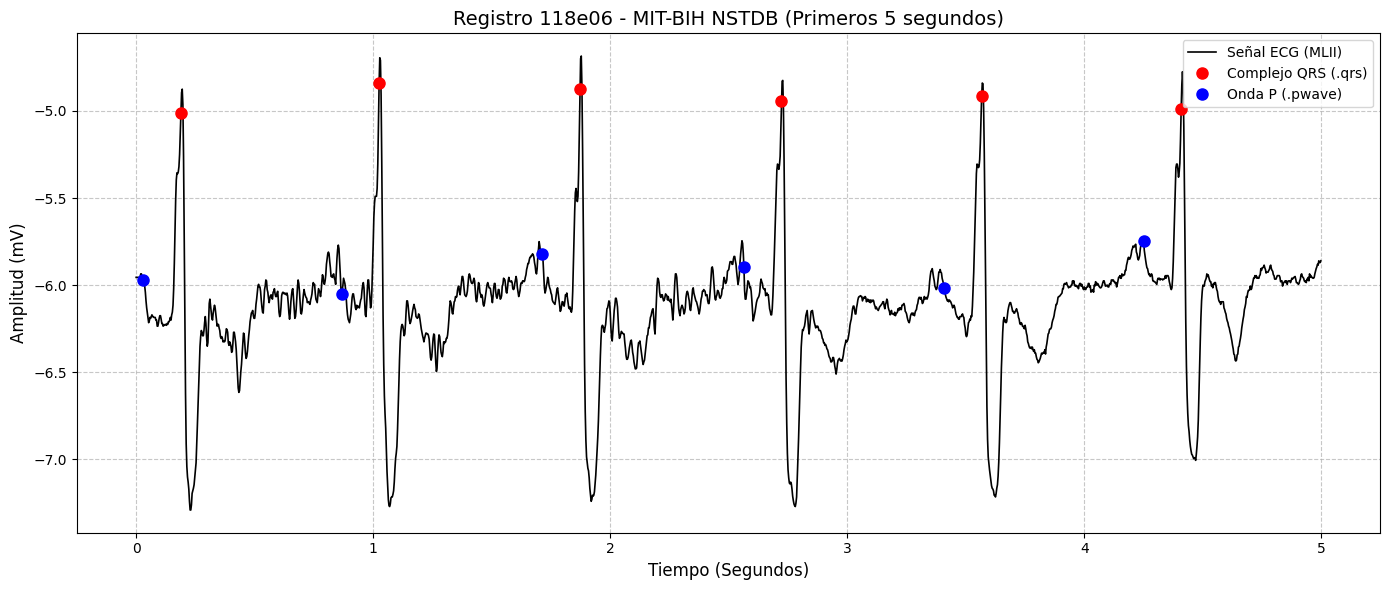

In [ ]:
# Gráfica
plt.figure(figsize=(14, 6))

# Graficar la señal de ECG continua
plt.plot(time_axis, signal, label=f'Señal ECG ({record.sig_name[0]})', color='black', linewidth=1.2)

# Superponer los marcadores de las anotaciones
plt.plot(qrs_indices / fs, record.p_signal[qrs_indices, 0], 'ro', markersize=8, label='Complejo QRS (.qrs)')
plt.plot(p_indices / fs, record.p_signal[p_indices, 0], 'bo', markersize=8, label='Onda P (.pwave)')

# Formato estético de la gráfica
plt.title(f'Registro {record_name} - MIT-BIH NSTDB (Primeros {end_sec} segundos)', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel(f'Amplitud ({record.units[0]})', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

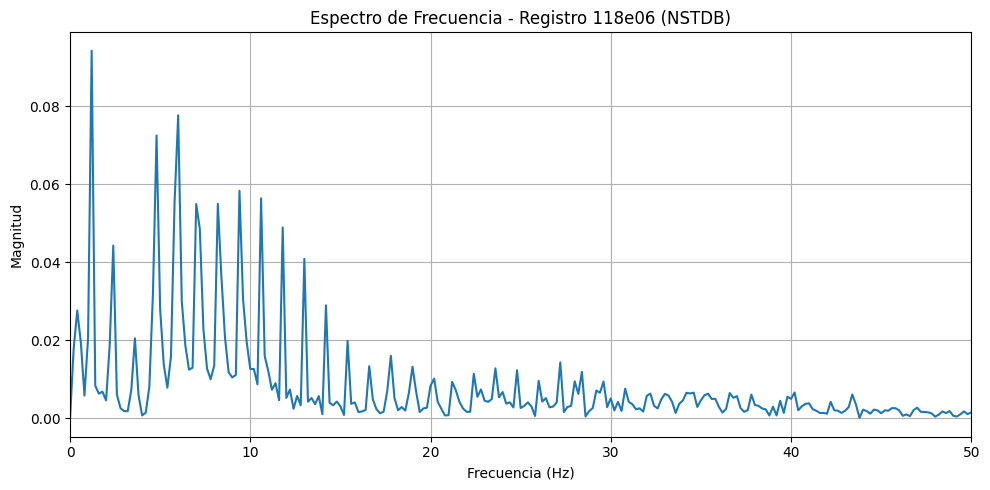

In [ ]:

# PREPROCESAMIENTO (RESTAR MEAN)
signal_centered = signal - np.mean(signal)

# FFT
N = len(signal_centered)

fft_values = np.fft.fft(signal_centered)
freqs = np.fft.fftfreq(N, d=1/fs)

# Solo frecuencias positivas
half_N = N // 2
fft_values = fft_values[:half_N]
freqs = freqs[:half_N]

# Magnitud
magnitude = np.abs(fft_values) / N

plt.figure(figsize=(10, 5))

plt.plot(freqs, magnitude)
plt.title(f'Espectro de Frecuencia - Registro {record_name} (NSTDB)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')

# En ECG siempre miramos bajas frecuencias
plt.xlim(0, 50)

plt.grid(True)
plt.tight_layout()
plt.show()